This notebook contains a computation of the nonlinear memory effect based on the polarizations $h_+$ and $h_\times$ given by PyCBC and the comparison with the memory given by the package `gwmemory`


### 1. Personal method 

We assumed that the $h_{22}$ mode is the dominant one, so we can use the following formula to compute the memory effect:
\begin{equation}
h^{\text{mem}}_{+}(t) = \frac{r}{192\pi} \sin^2{\theta}(17+ \cos^2{\theta}) \int_{-\infty}^{t_r} |\dot{h}_{22}(t')|^2 dt'
\end{equation}
where $\theta$ is the inclination angle ( 0 for North Pole and $\pi$ for South Pole), $r$ is the distance to the source and $h_{22}$ is the $(l=2, m=2)$ mode of the GW strain. The time $t_r$ is the retarded time defined as $t_r = t - r/c$, expressing the fact that the GW signal takes some time to reach the observer located at a distance $r$ from the source.

The mode $h_{22}$ can be obtained from the polarizations $h_+$ and $h_\times$ using the following relation:
\begin{equation}
h_+ - i h_\times = \sum_{l=2}^{\infty} \sum_{m=-l}^{l} h_{lm} \, {}_{-2}Y_{lm}(\theta, \phi)
\end{equation}
where ${}_{-2}Y_{lm}(\theta, \phi)$ are the spin-weighted spherical harmonics with spin weight -2 for the angles $\theta$ and $\phi$ defining the direction of the observer : $\theta$ is the inclination angle and $\phi$ is the azimuthal angle.

Assuming the dominant mode is $h_{22}$ only, we have:
\begin{equation}
h_{22} = \frac{h_+ - i h_\times}{{}_{-2}Y_{22}(\theta, \phi)}
\end{equation}
We can then compute the time derivative of $h_{22}$ numerically and perform the integration to obtain the memory effect.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pycbc
import gwmemory
import gwsurrogate

from pycbc.waveform import get_td_waveform
import lal
from lal import MSUN_SI, MTSUN_SI, PC_SI, C_SI, G_SI


/usr/local/lib64/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


lal.MSUN_SI != Msun


/usr/local/lib/python3.11/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


We define our spin-weighted spherical harmonic function as follows:

In [2]:
# Definition based on the article : https://arxiv.org/pdf/0812.0069#page=5.61
def fac(n): 
    if n==0 or n==1:
        return 1
    result = 1
    for i in range(2, n+1):
        result *= i
    return result

def dlms(l, m, s, Theta): # eq (2.14)
    fact1 = np.sqrt(fac(l+m)*fac(l-m)*fac(l+s)*fac(l-s))
    fact2 = 0.
    for k in range(max(0,m-s),min(l+m,l-s)+1):
        fact2 += (-1.)**k*np.sin(Theta/2.)**(2.*k+s-m)*np.cos(Theta/2.)**(2.*l+m-s-2.*k)/(fac(k)*fac(l+m-k)*fac(l-s-k)*fac(s-m+k))
    return fact1*fact2

def sYlm(s,l,m,Theta,Phi): # eq (2.13)
    fact = (-1.)**(-s)*np.sqrt((2.*l+1)/(4*np.pi))*dlms(l,m,-s,Theta)
    if fact==0:
        return 0.
    else:
        return complex(fact*np.cos(m*Phi), fact*np.sin(m*Phi)) # e^(imPhi)

These functions aim to compute the memory effect based on the dominant $h_{22}$ mode extracted from the polarizations $h_+$ and $h_\times$ of PyCBC waveforms for a extended waveform with a mass ratio of 1.

In [3]:
def generate_waveform_extended(mtot, deltaT, distance, inclination, approximant, extension_time=0.2):
    """
    Generate a waveform  with post-merger extension 
    """
    m1 = m2 = mtot / 2.0


    hp, hc = get_td_waveform(
        approximant=approximant,
        mass1=m1, mass2=m2,
        delta_t=deltaT,
        f_lower=20.,
        distance=distance,
        inclination=inclination
    )
    hp_orig = hp.numpy()
    hc_orig = hc.numpy()
    t_orig = hp.sample_times.numpy()

    # Align merger to t=0 by shifting time array
    amplitude = np.abs(hp_orig)
    merger_idx = np.argmax(amplitude)
    merger_time = t_orig[merger_idx]
    t_aligned = t_orig - merger_time

    # Extend waveform post-merger with zeros 
    n_extension = int(extension_time / deltaT)

    hp_extended = np.pad(hp_orig, (0, n_extension), mode='constant', constant_values=0)
    hc_extended = np.pad(hc_orig, (0, n_extension), mode='constant', constant_values=0)
    
    t_extension = np.arange(1, n_extension + 1) * deltaT + t_aligned[-1]
    t_extended = np.concatenate([t_aligned, t_extension])

    return t_extended, hp_extended, hc_extended


def generate_waveform_22(hp, hc, inclination, sqrt_two = False):
    """
    Compute the (2,2) mode from h+ and hx
    """
    h22 = (hp - 1.j * hc) / sYlm(-2, 2, 2, inclination, np.pi/2)
    if sqrt_two:
        h22 /= np.sqrt(2)
    return h22


def compute_memory_corrected(deltaT, h22, distance, inclination):
    """
    Compute the nonlinear memory effect from the h22 mode
    """
    dt = deltaT
    hdot = np.gradient(h22, dt)  
    hdot_c = np.conjugate(hdot)
    integrand = hdot * hdot_c
    cumint = np.cumsum(integrand) * dt  # Cumulative integral
    prefactor = (distance * 1e6 * PC_SI / C_SI) * (np.sin(inclination)) ** 2 * (17 + np.cos(inclination) ** 2) / (192 * np.pi)
    hmem = prefactor * cumint
    return np.real(hmem)

### 2. Using `gwmemory` package

We can compare our results with the memory effect computed using the `gwmemory` package, which provides a more comprehensive approach to calculating the memory effect by considering all relevant modes and contributions :

In [5]:
import gwmemory
total_mass = 60  # in solar masses
distance = 500  # in Mpc
inclination = np.pi / 2 # edge-on
delta_t = 1.0 / 4096  # time step in seconds
model_gwmemory = "IMRPhenomD"

t, hp_ext, hc_ext = generate_waveform_extended(
    mtot=total_mass,
    deltaT=delta_t,
    distance=distance,
    inclination=inclination,
    approximant="IMRPhenomD",
    extension_time=0.2
)
parameters = dict(
        total_mass=total_mass,
        distance=distance,
        inc=inclination,
        q=1.0,
        phase=0,
        spin_1=[0.0, 0.0, 0.0],
        spin_2=[0.0, 0.0, 0.0],
        times=t,
        model=model_gwmemory
        )


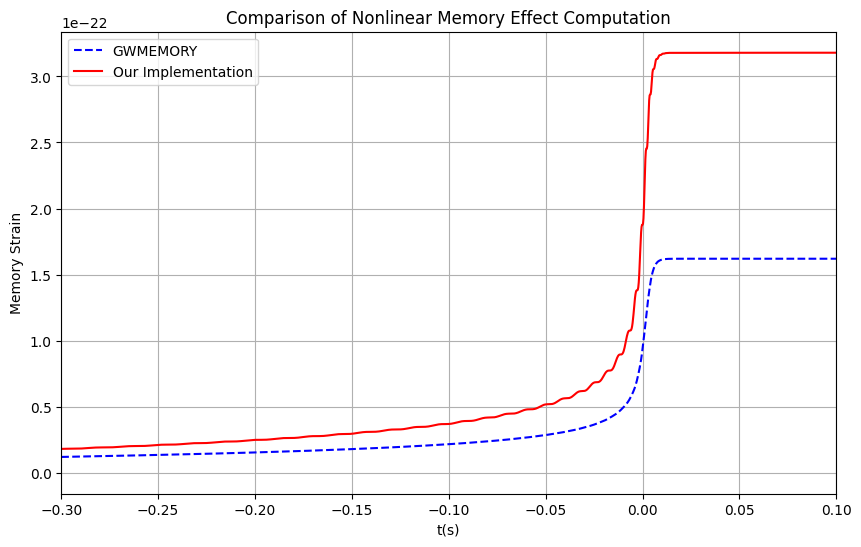

In [6]:
# Compute memory using gwmemory 
h_mem_gwmemory, t_mem_gwmemoy= gwmemory.time_domain_memory(**parameters)

# Compute memory using our implementation
h22 = generate_waveform_22(hp_ext, hc_ext, inclination)
h_mem_our = compute_memory_corrected(delta_t,h22, distance, inclination)

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(t_mem_gwmemoy, h_mem_gwmemory['plus'], label='GWMEMORY', linestyle='--', color='blue')
plt.plot(t, h_mem_our, label='Our Implementation', linestyle='-', color='red')
plt.xlabel('t(s)')
plt.ylabel('Memory Strain')
plt.title('Comparison of Nonlinear Memory Effect Computation')
plt.xlim(-0.3, 0.1)
plt.legend()
plt.grid()
plt.show()

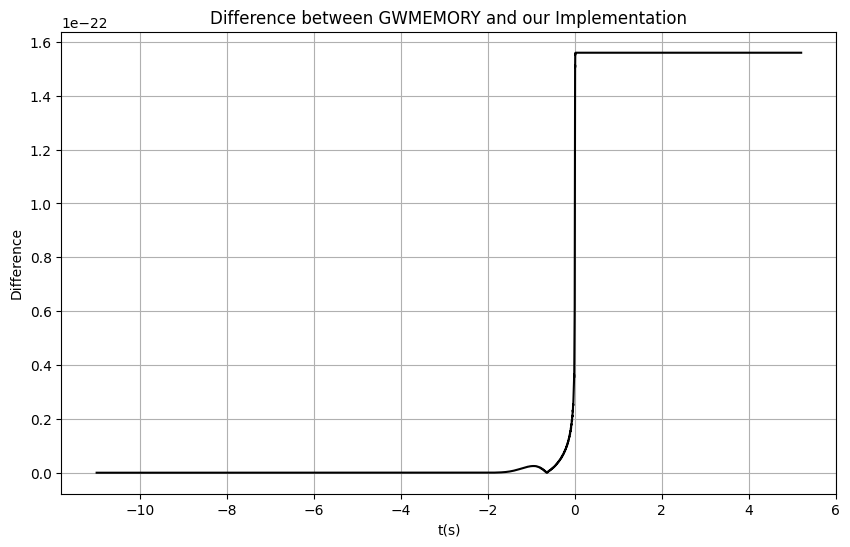

In [7]:
# Relative difference plot
relative_difference = np.abs(h_mem_our - h_mem_gwmemory['plus'])
plt.figure(figsize=(10, 6))
plt.plot(t, relative_difference, color='k')
plt.xlabel('t(s)')
plt.ylabel('Difference')
plt.title('Difference between GWMEMORY and our Implementation')
plt.grid()
plt.show()

After further analysis, we supposed that the issue could come from a factor include in the definition of the h22 mode. The exact value of the mismatch is still under investigation but it seems to be a factor $\sqrt{2}$ leading to an overestimation of the memory computed with our personal method by a factor 2.

Let's check if we divide our h22 by a factor $\sqrt{2}$. We obtain a much better agreement between the two methods. This factor could come from a different normalization convention used in the definition of the spin-weighted spherical harmonics or in the waveform generation process. Further investigation would be needed to pinpoint the exact source of this discrepancy.

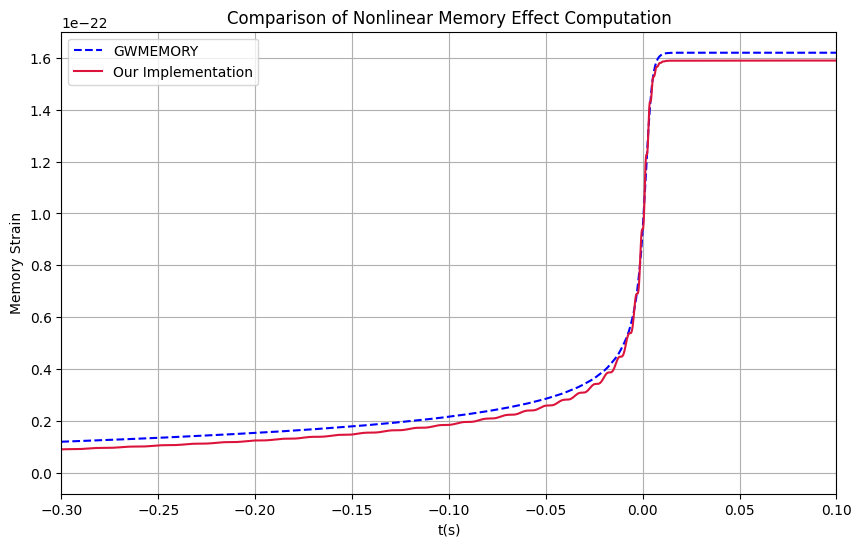

In [8]:
# Compute memory using our implementation
h22 = generate_waveform_22(hp_ext, hc_ext, inclination, sqrt_two=True)
h_mem_our = compute_memory_corrected(delta_t, h22, distance, inclination)

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(t_mem_gwmemoy, h_mem_gwmemory['plus'], label='GWMEMORY', linestyle='--', color='blue')
plt.plot(t, h_mem_our, label='Our Implementation', linestyle='-', color='crimson')
plt.xlabel('t(s)')
plt.ylabel('Memory Strain')
plt.title('Comparison of Nonlinear Memory Effect Computation')
plt.xlim(-0.3, 0.1)
plt.legend()
plt.grid()
plt.show()

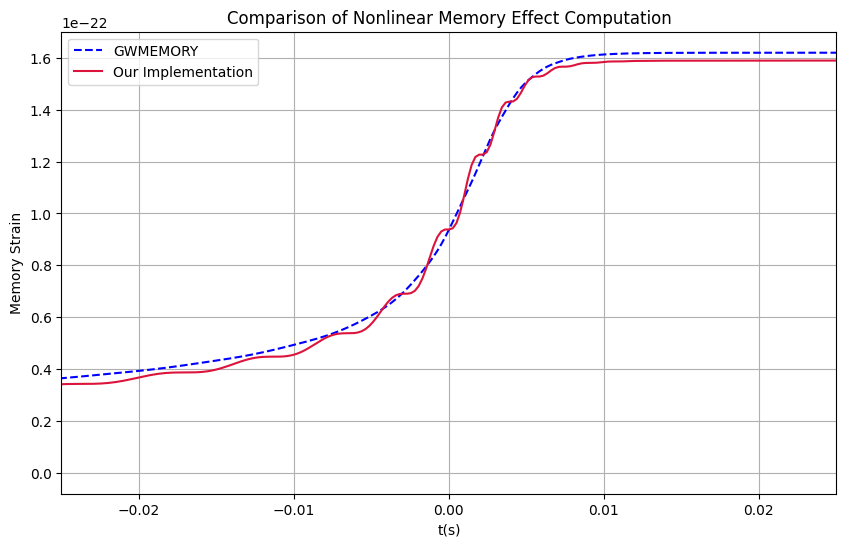

In [9]:
# Zoom
plt.figure(figsize=(10, 6))
plt.plot(t_mem_gwmemoy, h_mem_gwmemory['plus'], label='GWMEMORY', linestyle='--', color='blue')
plt.plot(t, h_mem_our, label='Our Implementation', linestyle='-', color='crimson')
plt.xlabel('t(s)')
plt.ylabel('Memory Strain')
plt.title('Comparison of Nonlinear Memory Effect Computation')
plt.xlim(-0.025, 0.025)
plt.legend()
plt.grid()
plt.show()

Remark : The spin-weighted spherical harmonics used in the personal method are identical to those used in the `gwmemory` package, so the discrepancy is unlikely to stem from differences in their definitions

In [10]:
from gwmemory import angles
Y_mem_gwmemory = angles.harmonics.sYlm(-2, 2, 2, np.pi/2, np.pi/2)
Y_mem_perso = sYlm(-2, 2, 2, np.pi/2, np.pi/2)
print('ratio Ylm gwmemory / perso (edge-on): ', Y_mem_gwmemory / Y_mem_perso)

ratio Ylm gwmemory / perso (edge-on):  (0.9999999999999998-0j)


---

Solution : Using the completness relation of the spin-weighted spherical harmonics, we can express the $h_{22}$ mode in terms of the polarizations $h_+$ and $h_\times$ as follows:
\begin{equation*}
h_{22} = \int (h_+ - i h_\times) \,{}_{-2}\bar{Y}_{22}(\theta, \phi) \, d\Omega
\end{equation*}
where $d\Omega = \sin{\theta} d\theta d\phi$ is the solid angle element. As the spin-weighted spherical harmonics form a complete basis, the completness relation writes :
\begin{equation*}
    \sum_{\ell m} {}_s\bar{Y}_{\ell m}(\theta', \phi') ~{}_sY_{\ell m}(\theta, \phi)  = \delta(\phi' - \phi)~\delta (\cos{\theta'}- \cos{\theta})\ ,
\end{equation*}

/usr/local/lib64/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib64/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


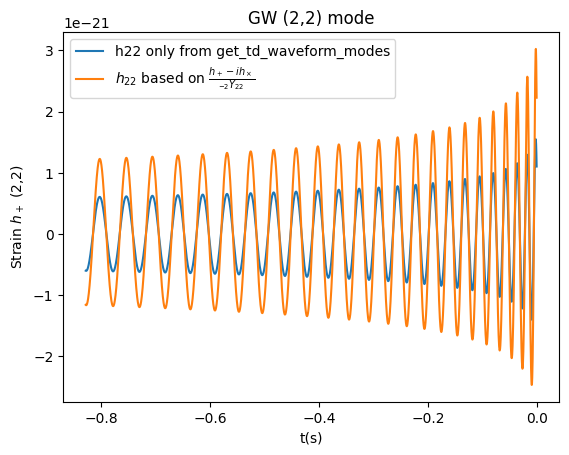

In [11]:
from pycbc.waveform import get_td_waveform_modes

# Example parameters
approximant = "TaylorT4"
mass1 = 30
mass2 = 30
delta_t = 1.0 / 4096
f_lower = 20.
distance = 500  # Mpc
inclination = np.pi/2  # radians

# Generate only the (2,2) mode
modes = get_td_waveform_modes(
    approximant=approximant,
    mass1=mass1,
    mass2=mass2,
    delta_t=delta_t,
    f_lower=f_lower,
    distance=distance,
    inclination=inclination
)
# Access the (2,2) mode time series
hp22 = modes.get((2,2))[0]
t = hp22.sample_times

plt.plot(t, hp22, label ='h22 only from get_td_waveform_modes')
plt.xlabel("t(s)")
plt.ylabel("Strain $h_+$ (2,2)")
plt.title("GW (2,2) mode")


hp, hc = get_td_waveform(
    approximant=approximant,
    mass1=mass1,
    mass2=mass2,
    delta_t=delta_t,
    f_lower=f_lower,
    distance=distance,
    inclination=inclination,
)

plt.plot(hp.sample_times, (hp-1.j*hc)/sYlm(-2,2,2,np.pi/2, np.pi/2), label = r'$h_{22}$ based on $\frac{h_+ - i h_\times}  {{}_{-2}Y_{2 2}}$')
plt.legend()
plt.show()


In [12]:
x = np.mean((hp/sYlm(-2,2,2,np.pi/2, np.pi/2))/ hp22)
print(x)
print(np.real(1/x))
print(1/np.sqrt(2))
print(sYlm(-2,2,2,np.pi/2, np.pi/2))


(1.9115356746060277+2.3409560453622483e-16j)
0.5231395957107118
0.7071067811865475
(-0.15769578262626005+1.9312163543228616e-17j)


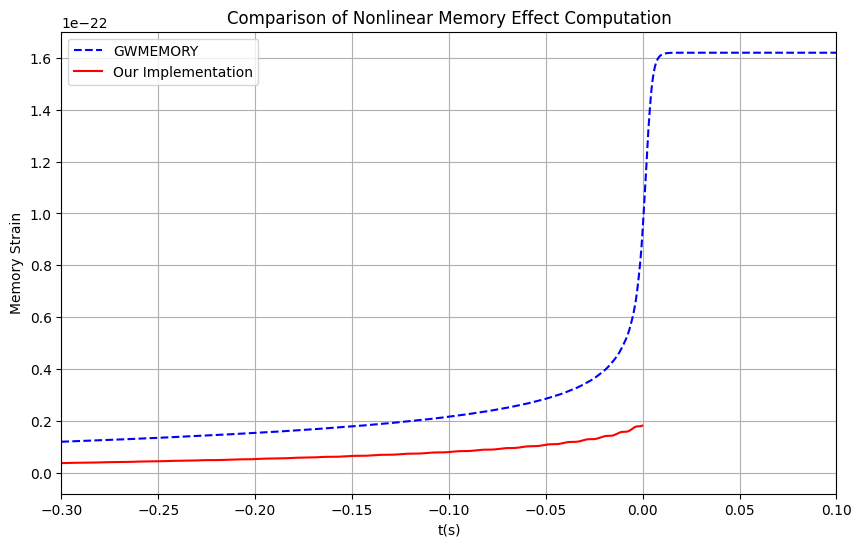

In [13]:
h_mem_our = compute_memory_corrected(delta_t, hp22, distance, inclination)
# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(t_mem_gwmemoy, h_mem_gwmemory['plus'], label='GWMEMORY', linestyle='--', color='blue')
plt.plot(t, h_mem_our, label='Our Implementation', linestyle='-', color='red')
plt.xlabel('t(s)')
plt.ylabel('Memory Strain')
plt.title('Comparison of Nonlinear Memory Effect Computation')
plt.xlim(-0.3, 0.1)
plt.legend()
plt.grid()
plt.show()

### Other method : Use surrogate model NRHyb3dq8

In [1]:
%pip install gwsurrogate

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import gwsurrogate as gws
import gwtools

gws.catalog.list()
gws.catalog.list(verbose=True) 

EOBNRv2
SpEC_q1_10_NoSpin
SpEC_q1_10_NoSpin_linear
SpEC_q1_10_NoSpin_linear_alt
NRSur4d2s_TDROM_grid12
NRSur4d2s_FDROM_grid12
NRHybSur3dq8
NRHybSur3dq8_CCE
NRHybSur2dq15
NRSur7dq4
SEOBNRv4PHMSur
NRHybSur3dq8Tidal
EMRISur1dq1e4
BHPTNRSur1dq1e4
EOBNRv2
  url: https://www.dropbox.com/scl/fi/8tyein6dmc1mfzmtbp56b/EOBNRv2.tar.gz?rlkey=3j80zg9vn79744p9w9ttemug2&e=1&st=rrp9ubx2&dl=1
  md5 hash: e8c7ded3b533c7b13df973155c36badb
  Description:  Collection of single mode surrogates from mass ratios 1 to 10,
               as long as 190000M and modes (2,1), (2,2), (3,3), (4,4), (5,5). This is not
               a true multi-mode surrogate, and relative time/phase information between the
               modes have not been preserved.
  References: http://journals.aps.org/prx/abstract/10.1103/PhysRevX.4.031006

SpEC_q1_10_NoSpin
  url: https://zenodo.org/record/3348115/files/SpEC_q1_10_NoSpin_nu5thDegPoly_exclude_2_0.h5
  md5 hash: 4d08862a85437e76a1634dae6d984fdb
  Description: A multimode surroga

In [5]:
sur = gws.LoadSurrogate('NRHybSur3dq8_CCE')

Surrogate data not found for NRHybSur3dq8_CCE. Downloading now.
Loaded NRHybSur3dq8_CCE model


we can try to reproduce the last figure of https://cds.cern.ch/record/2953967/files/2601.23019.pdf#page=9.61

Available modes: [(2, -2), (2, -1), (2, 0), (2, 1), (2, 2), (3, -3), (3, -2), (3, 0), (3, 2), (3, 3), (4, -4), (4, -3), (4, 0), (4, 3), (4, 4), (5, -5), (5, 5)]


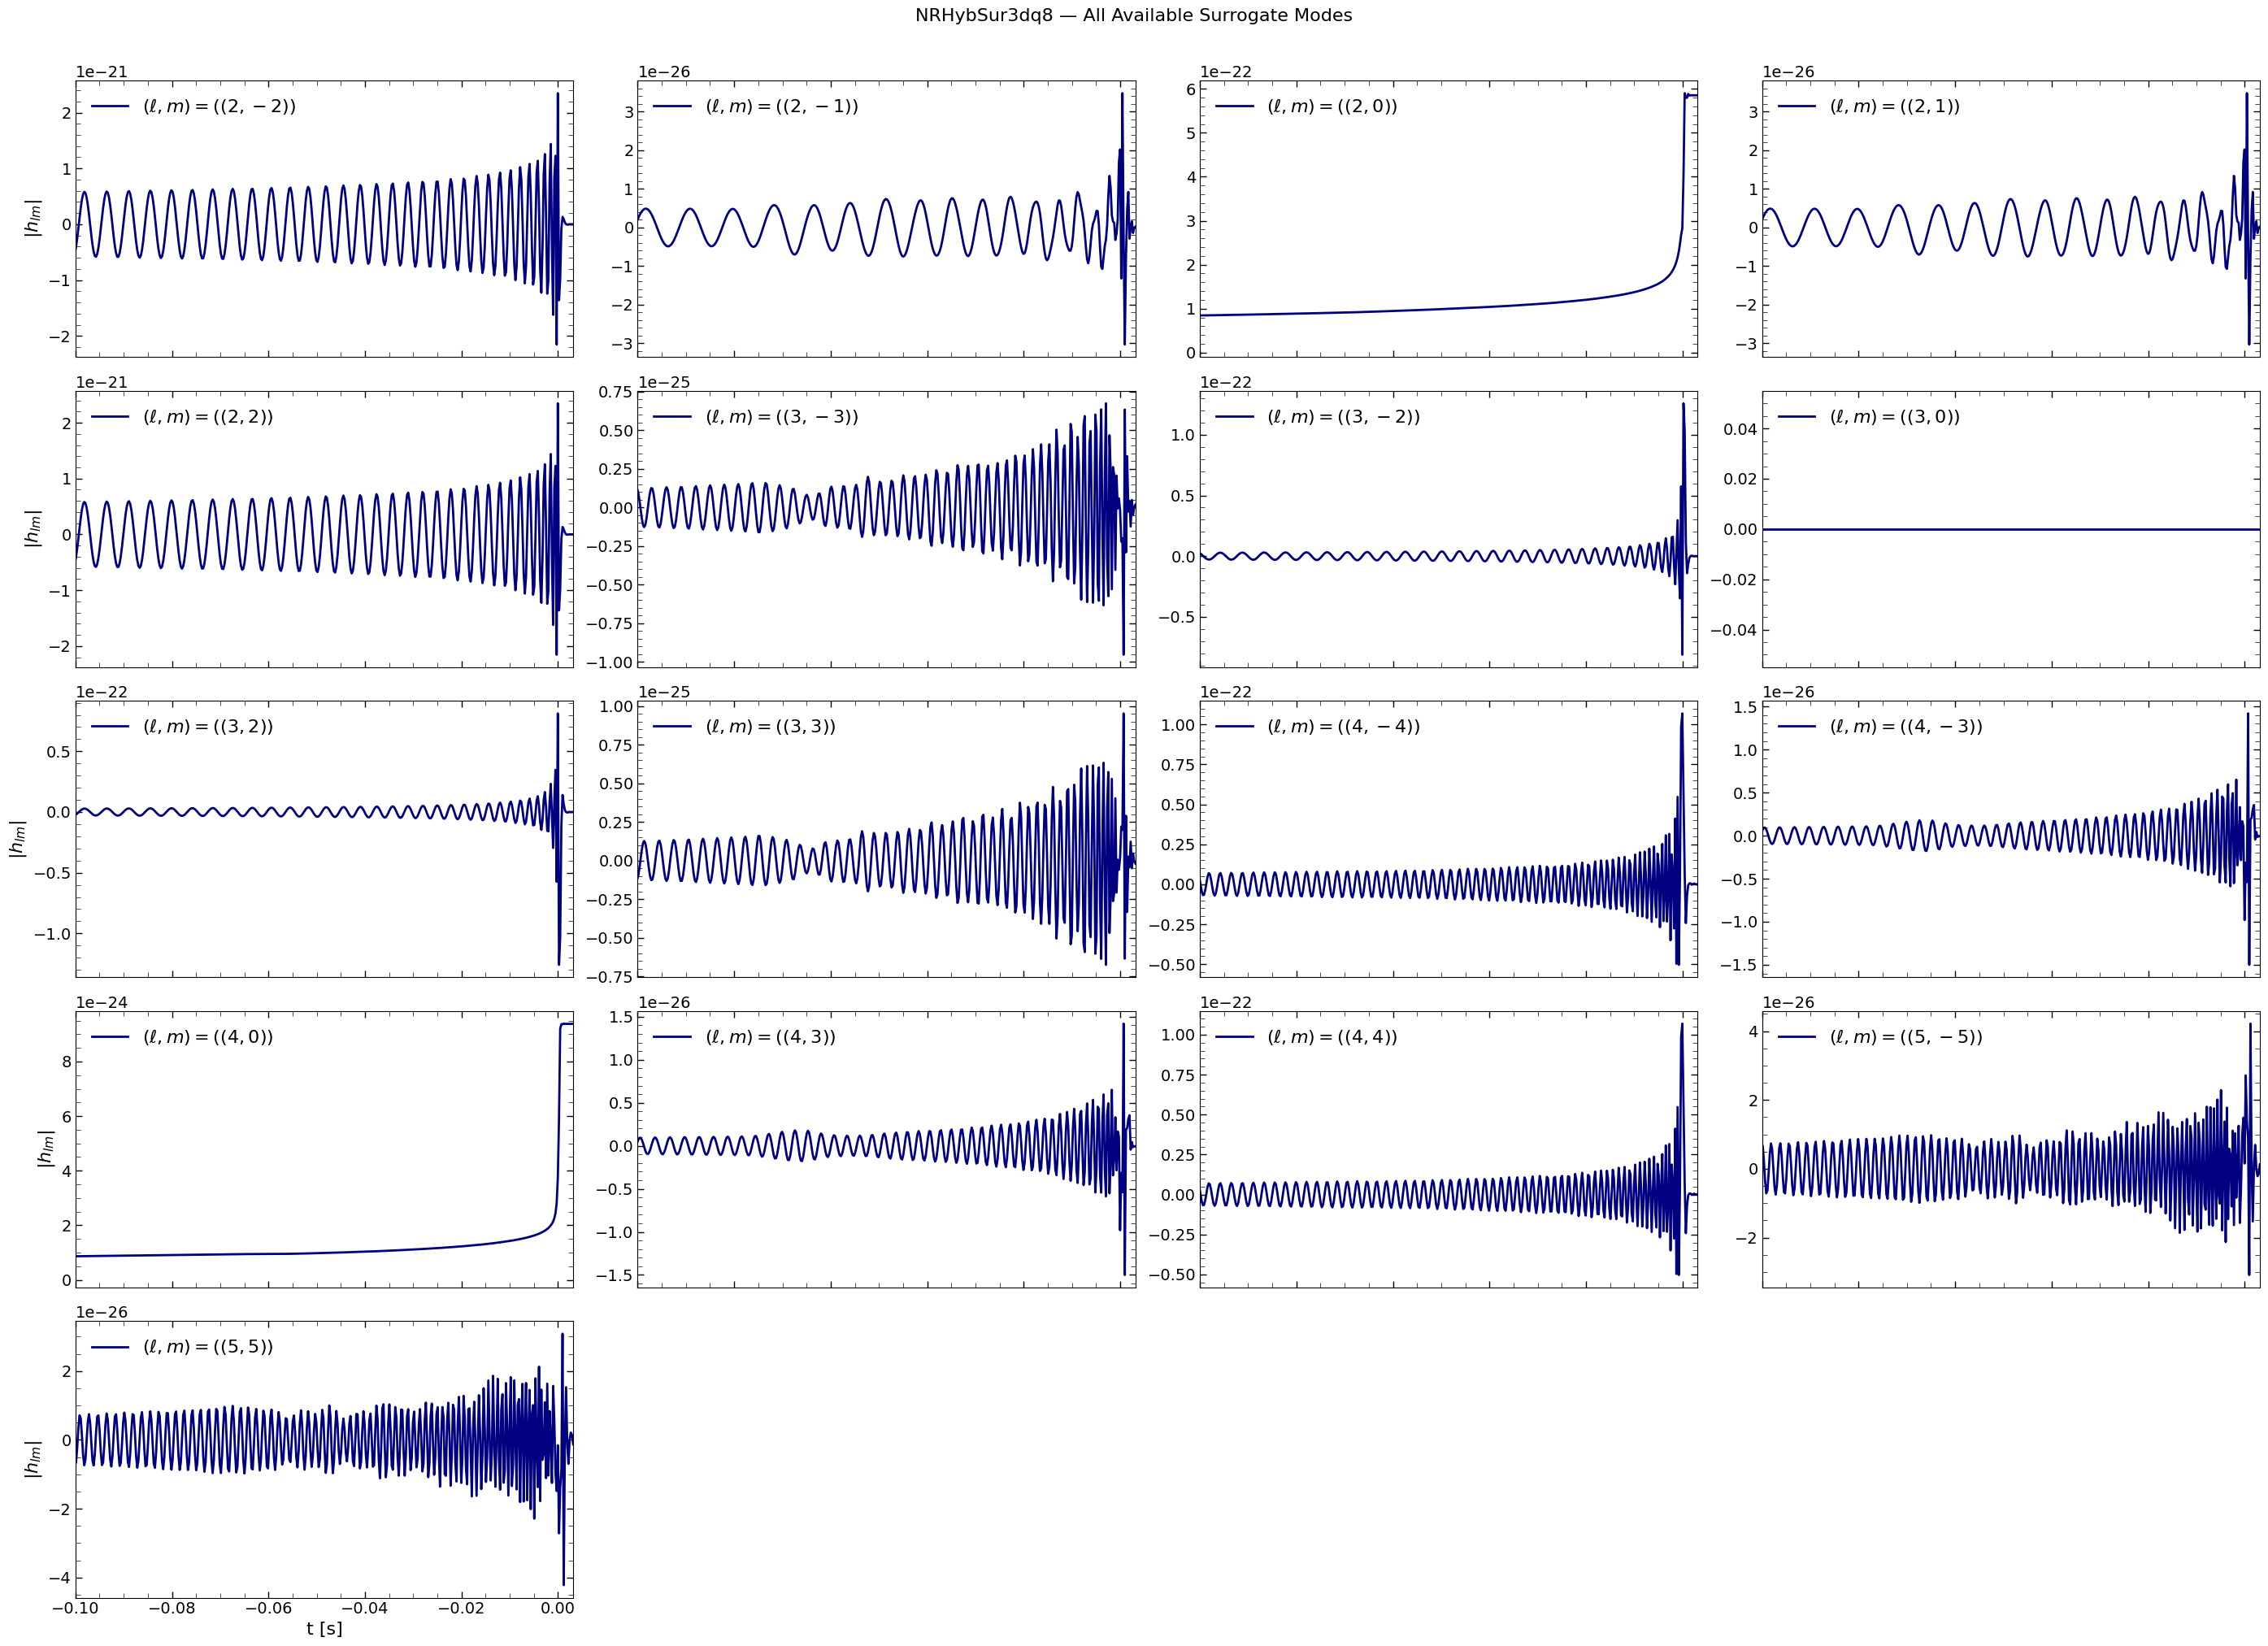

In [6]:
q = 1
chiA = [0, 0, 0.]
chiB = [0, 0, 0.]
M = 5            
dist_mpc = 40      
dt = 1./4096  
f_low = 20         

# Call WITHOUT inclination/phi_ref to get a mode dictionary
t_all, h_all, dyn_all = sur(q, chiA, chiB, dt=dt, f_low=f_low, M=M, dist_mpc=dist_mpc, units='mks')

# Get all available modes from the returned dictionary keys
all_modes = sorted(h_all.keys())
print("Available modes:", all_modes)

# Determine grid layout
n_modes = len(all_modes)
ncols = 4
nrows = int(np.ceil(n_modes / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(28, 4 * nrows), sharex=True)
axes = axes.flatten()

for i, mode in enumerate(all_modes):
    h_mode = h_all[mode]
    axes[i].plot(t_all, h_mode.real, label=f'$(\ell, m) = ({mode[0], mode[1]})$', color='navy', lw= 2)
    axes[i].set_xlim(-0.1, t_all[-1])
    axes[i].legend(loc = 'upper left', frameon=False, fontsize=16)

if i ==len(all_modes)-1:
    axes[i].set_xlabel('t [s]')
# Label y-axis for leftmost plots
for j in range(nrows):
    axes[j * ncols].set_ylabel('$|h_{lm}|$')

# Hide unused subplots
for k in range(n_modes, len(axes)):
    axes[k].set_visible(False)

fig.suptitle('NRHybSur3dq8 — All Available Surrogate Modes', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

Loaded NRSur7dq4 model
Loaded NRSur7dq4 model


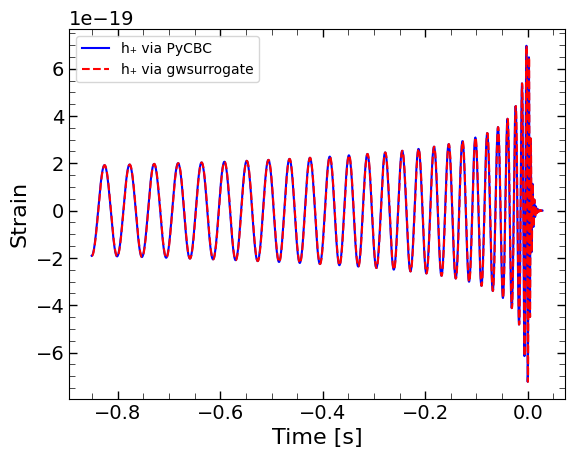

In [6]:
from pycbc.waveform import get_td_waveform
import gwsurrogate as gws
import matplotlib.pyplot as plt

# PyCBC waveform
hp_pcbc, hc_pcbc = get_td_waveform(approximant="GWS-NRSur7dq4",mass1=30, mass2=30, delta_t=1.0/2048,f_lower=20.0,f_ref=20.0)

# gwsurrogate waveform
sur = gws.LoadSurrogate("NRSur7dq4")
t, h, dynamics = sur(q=1.0, chiA0=[0, 0, 0], chiB0=[0, 0, 0], M=60.0, dt=1.0/2048, f_low=20.0, dist_mpc=1.0, units="mks", inclination=0.0, phi_ref=0.0, f_ref=20.0)

# Plot comparison
plt.plot(hc_pcbc.sample_times, hp_pcbc, 'b', label='h₊ via PyCBC')
plt.plot(t, h.real, 'r--', label='h₊ via gwsurrogate')
plt.xlabel("Time [s]")
plt.ylabel("Strain")
plt.legend()
plt.show()

Loaded NRHybSur3dq8 model


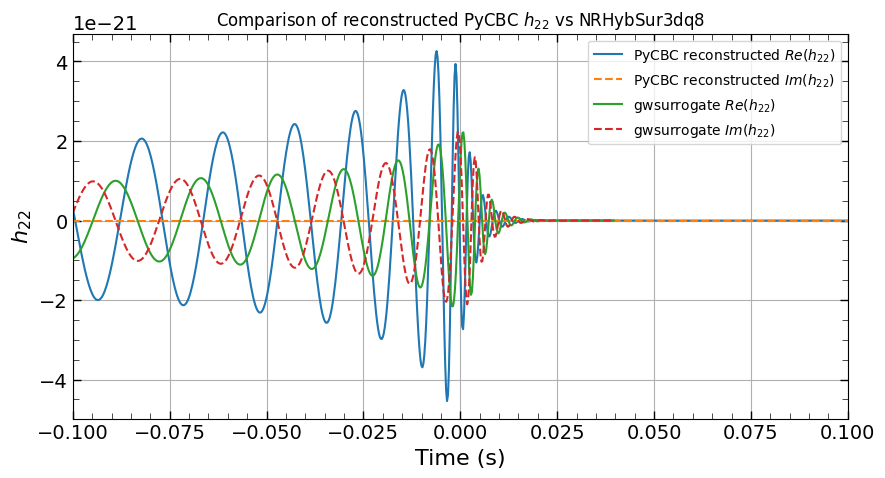

In [7]:
mass1 = 30
mass2 = 30
M = mass1 + mass2
q = mass1 / mass2
chiA = [0, 0, 0]
chiB = [0, 0, 0]
delta_t = 1.0 / 4096
f_lower = 20.
distance = 500  # Mpc
inclination = np.pi/2  # radians

# PyCBC waveform (polarizations) 
from pycbc.waveform import get_td_waveform
hp, hc = get_td_waveform(
    approximant="IMRPhenomD",
    mass1=mass1,
    mass2=mass2,
    delta_t=delta_t,
    f_lower=f_lower,
    distance=distance,
    inclination=inclination,
)
t_pycbc = hp.sample_times.numpy()
hp_np = hp.numpy()
hc_np = hc.numpy()

# Old way 

def generate_waveform_22(hp, hc, inclination, sqrt_two=False):
    h22 = (hp - 1.j * hc) / sYlm(-2, 2, 2, inclination, np.pi/2)
    if sqrt_two:
        h22 /= np.sqrt(2)
    return h22

h22_pycbc_recon = generate_waveform_22(hp_np, hc_np, inclination)

#  gwsurrogate waveform (NRHybSur3dq8)
import gwsurrogate as gws
sur = gws.LoadSurrogate('NRHybSur3dq8')
t, hlm, dyn = sur(1, chiA, chiB, M=M, dist_mpc = distance, dt=delta_t, f_low=f_lower, mode_list=[(2,2)], units='mks')
t_gws = t 
h22_gws = hlm[(2,2)]

# Plot comparison 
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(t_pycbc, h22_pycbc_recon.real, label="PyCBC reconstructed $Re(h_{22})$")
plt.plot(t_pycbc, h22_pycbc_recon.imag, label="PyCBC reconstructed $Im(h_{22})$", linestyle='--')
plt.plot(t_gws, h22_gws.real, label="gwsurrogate $Re(h_{22})$")
plt.plot(t_gws, h22_gws.imag, label="gwsurrogate $Im(h_{22})$", linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("$h_{22}$")
plt.title("Comparison of reconstructed PyCBC $h_{22}$ vs NRHybSur3dq8")
plt.xlim(-0.1, 0.1)
plt.legend()
plt.grid()
plt.show()

In [8]:
help(sur)

Help on NRHybSur3dq8 in module gwsurrogate.surrogate object:

class NRHybSur3dq8(SurrogateEvaluator)
 |  NRHybSur3dq8(h5filename)
 |  
 |  A class for the NRHybSur3dq8 surrogate model presented in Varma et al. 2018,
 |  arxiv:1812.07865.
 |  
 |  Evaluates gravitational waveforms generated by aligned-spin binary black hole
 |  systems. This model was built using numerical relativity (NR) waveforms that
 |  have been hybridized using post-Newtonian (PN) and effective one body (EOB)
 |  waveforms.
 |  
 |  This model includes the following spin-weighted spherical harmonic modes:
 |  (2,2), (2,1), (2,0), (3,3), (3,2), (3,1), (3,0), (4,4) (4,3), (4,2) and (5,5).
 |  The m<0 modes are deduced from the m>0 modes.
 |  
 |  The parameter space of validity is:
 |  q \in [1, 10] and chi1z/chi2z \in [-1, 1],
 |  where q is the mass ratio and chi1z/chi2z are the spins of the heavier/lighter
 |  BH, respectively, in the direction of orbital angular momentum.
 |  
 |  The surrogate has been trained 

Calculate memory using surrogate model NRHyb3dq8 from PyCBC and compare with gwmemory package

In [8]:
from matplotlib.ticker import MultipleLocator

#memory with surrogate model NRHyb3dq8
distance = 500  # Mpc
inclination = np.pi / 2 # edge-on
delta_t = 1.0 / 4096  # time step in seconds
hmem_sur = compute_memory_corrected(delta_t, h22_gws, distance, inclination)

# Décalage vertical pour que hmem_sur[t = -2.5] = 0
index_t_minus_2_5 = np.argmin(np.abs(t_gws - (-0.25)))  # Trouver l'indice correspondant à t = -2.5
#hmem_sur -= hmem_sur[index_t_minus_2_5]

plt.plot(t_gws, hmem_sur)
plt.xlabel("t(s)", fontsize=12)
plt.ylabel("$h_+^{mem}$", fontsize=12)
plt.title("Nonlinear Memory Effect from NRHyb3dq8")
plt.xlim(-0.25, 0.025)
plt.tick_params(axis='both', which='minor', labelsize=12, direction='in')
plt.gca().yaxis.set_major_locator(MultipleLocator(0.05 * 1e-21))
plt.grid()
plt.show()

NameError: name 'h22_gws' is not defined

Comparison with GWmemory

Loaded SEOBNRv4PHMSur model


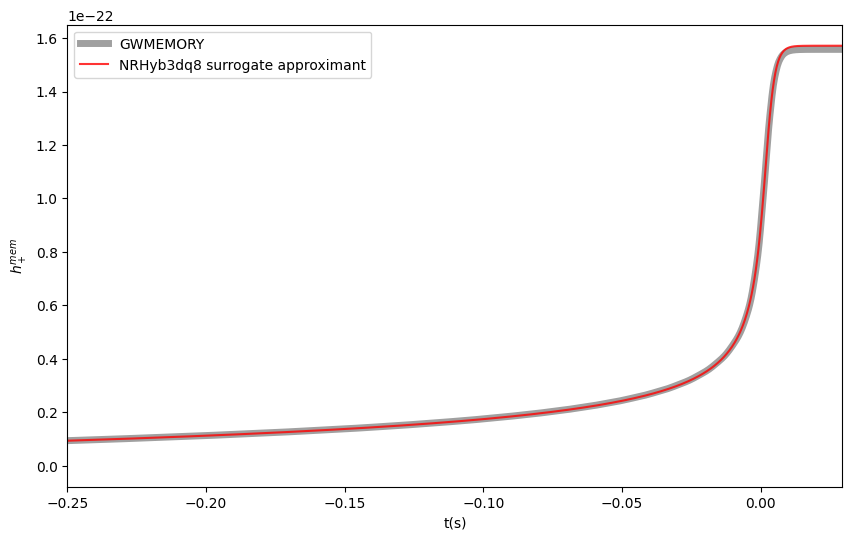

In [ ]:
sur = gws.LoadSurrogate('SEOBNRv4PHMSur')
delta_t = 1/4096
f_lower = 20.
t, hlm, dyn = sur(1, [0,0,0], [0,0,0], M=60, dist_mpc = 500, dt=delta_t, f_low=f_lower, ellMax=2, units='mks')
h22_sur = hlm[(2,2)]
hmem_sur = compute_memory_corrected(delta_t, h22_sur, 500, np.pi/2)
parameters = dict(
        total_mass=60,
        distance=500,
        inc=np.pi/2,
        q=1.0,
        phase=0,
        spin_1=[0.0, 0.0, 0.0],
        spin_2=[0.0, 0.0, 0.0],
        times=t,
        model=model_gwmemory
        )
h_mem_gwmemory, t_mem_gwmemoy= gwmemory.time_domain_memory(**parameters)


plt.figure(figsize=(10, 6))
plt.plot(t_mem_gwmemoy, h_mem_gwmemory['plus'], label='GWMEMORY', linestyle='-', color='grey', lw= 5, alpha = 0.75)
plt.plot(t, hmem_sur, label='NRHyb3dq8 surrogate approximant', linestyle='-', color='red', alpha=0.8)
plt.xlabel('t(s)')
plt.ylabel('$h_+^{mem}$')
plt.legend(loc='best')
plt.xlim(-0.25, t[-1])
plt.show()

---

Test with mode_array

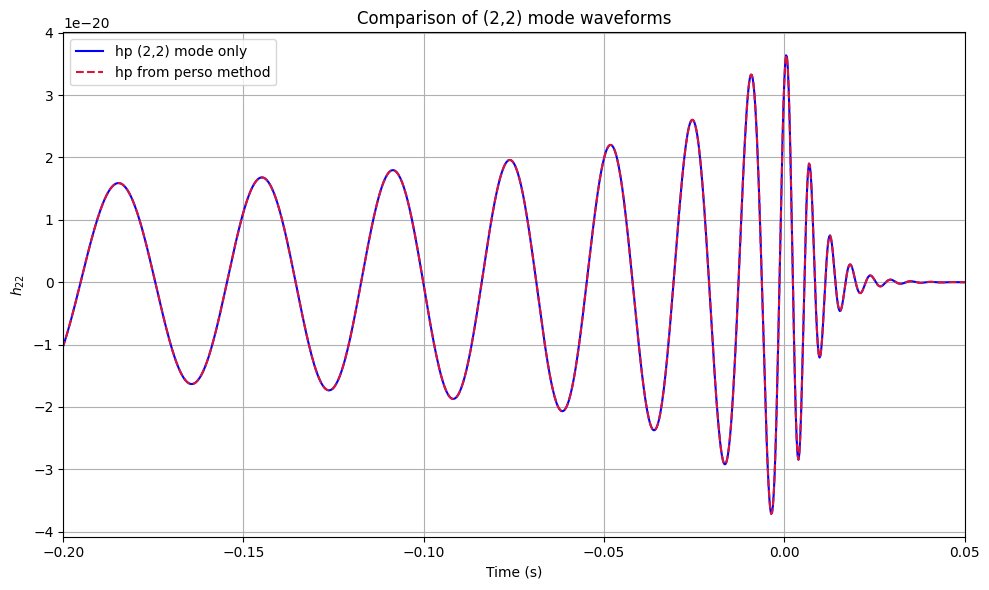

In [ ]:
# Get a waveform with only the (2, 2) mode
m1 = m2 = 50
inclination = np.pi/2
deltaT = 1.0 / 4096
hp_22, hc_22 = get_td_waveform(
    approximant="SEOBNRv4",
    mass1=m1,
    mass2=m2,
    f_lower=20.0,
    mode_array=[(2, 2),(2,-2)],
    inclination=inclination,
    delta_t=deltaT, 
    distance = 100
)
h22_modes =  (hp_22.numpy()- 1.j*hc_22) /sYlm(-2,2,2,np.pi/2, np.pi/2)
# hp_22 and hc_22 are the plus and cross polarization containing only the (2,2) mode -> need to project on sYlm(-2,2,2,.,.) to get h22
# compare with the one from the function 
hp, hc = get_td_waveform(
        approximant='SEOBNRv4',
        mass1=m1, mass2=m2,
        lambda1=0, lambda2=0,
        delta_t=deltaT,
        f_lower=20.,
        distance=100, 
        inclination=inclination, 
        tc=0.0,
        spin_1z=0.0, spin_2z=0.0, 
        spin_1y=0.0, spin_2y=0.0,
        spin_1x=0.0, spin_2x=0.0, 
        phase = 0.0
    )

h22_perso = generate_waveform_22(hp, hc, inclination=inclination)
h22_perso = h22_perso.numpy()

plt.figure(figsize=(10,6))
plt.plot(hp_22.sample_times.numpy(),h22_modes, label='hp (2,2) mode only', color='blue')# Projection on (2,2)
plt.plot(hp.sample_times.numpy(), np.real(h22_perso), label='hp from perso method', color='crimson', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('$h_{22}$')
plt.title('Comparison of (2,2) mode waveforms')
plt.legend()
plt.grid()
plt.xlim(-0.2, 0.05)
plt.tight_layout()
plt.show()

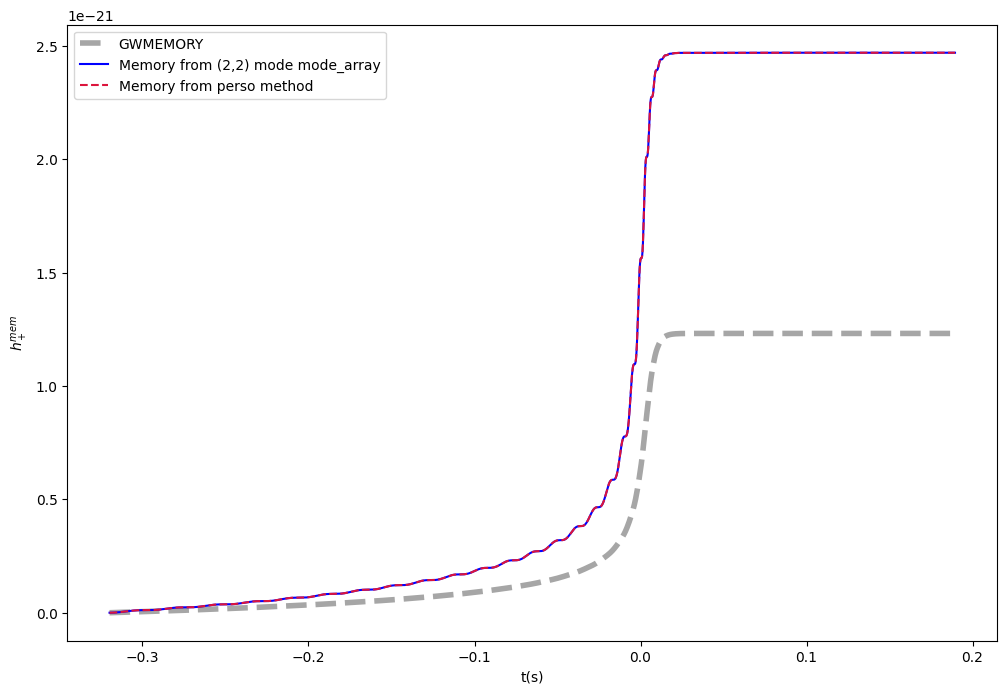

In [ ]:
# compute the memory of both methods and compare with gwmemory
h_mem_modes =compute_memory_corrected(deltaT, h22_modes.numpy(), distance=100, inclination=np.pi/2)

h_mem_classical = compute_memory_corrected(deltaT, h22_perso, distance=100, inclination=np.pi/2)

parameters = dict(
        total_mass=100,
        distance=100,
        inc=np.pi/2,
        q=1.0,
        phase=0,
        spin_1=[0.0, 0.0, 0.0],
        spin_2=[0.0, 0.0, 0.0],
        times=hp_22.sample_times.numpy(),
        model='SEOBNRv4'
        )
h_mem_gwmemory, t_mem_gwmemoy= gwmemory.time_domain_memory(**parameters)

plt.figure(figsize =(12,8))
plt.plot(t_mem_gwmemoy, h_mem_gwmemory['plus'], label='GWMEMORY', linestyle='--', color='grey', lw=4, alpha=0.7)
plt.plot(hp_22.sample_times.numpy(), h_mem_modes, label='Memory from (2,2) mode mode_array', color='blue')
plt.plot(hp.sample_times.numpy(), h_mem_classical, label='Memory from perso method', color='crimson', linestyle='--')
plt.xlabel('t(s)')
plt.ylabel('$h_+^{mem}$') 
plt.legend(loc='best')
plt.show()

### Compute the max of the nonlinrar memory for different approximant and different \ell m modes

In [9]:
# Voir "Enhancing Gravitational Wave Parameter Estimation with Non-Linear Memory: Breaking the Distance-Inclination Degeneracy" eq (1) et (2)
from sympy.physics.wigner import wigner_3j
def G_ang_int(l1,l2,l3,m1,m2,m3):

	eval = (-1.)**(m1+m2) * np.sqrt(((2.*l1+1.)*(2.*l2+1.)*(2.*l3+1.))/(4.*np.pi)) * wigner_3j(l1,l2,l3,0,2,-2) * wigner_3j(l1,l2,l3,-m1,m2,-m3)

	return float(eval) 
# Fonction principale pour calculer la mémoire pour un mode (l,m) donné
def compute_memory_mode(l, m, h_modes, times, distance):
    """
    Calcule l'amplitude de mémoire pour un mode (l,m) donné
    
    Paramètres:
    -----------
    l, m : int
        Indices du mode de mémoire à calculer
    h_modes : dict
        Dictionnaire des modes {(l', m'): h_l'm'(t)} 
    times : array
        Grille temporelle
    distance : float
        Distance en Mpc
  
    Return:
    ---------
    h_mem_lm : array
        Amplitude de mémoire pour le mode (l,m)
    """
    import numpy as np
    from lal import C_SI, PC_SI
    
    # Constantes
    R = distance * 1e6 * PC_SI  # Convertir Mpc en mètres
    c = C_SI
    dt = times[1] - times[0]
    
    # Préfacteur 
    prefactor = (R / c) * np.sqrt(fac(l - 2) / fac(l + 2))
    
    # Initialisation de l'intégrale
    cumulative_integral = np.zeros(len(times), dtype=complex)
    # Sommes sur tous les modes disponibles
    for (l_prime, m_prime), h_lp_mp in h_modes.items():
        for (l_double_prime, m_double_prime), h_ldp_mdp in h_modes.items():
            
            # Vérification que l', l'' >= 2 (modes physiques)
            if l_prime < 2 or l_double_prime < 2:
                continue
                
            # Calcul de l'intégrale angulaire G
            G_factor = G_ang_int(l, l_prime, l_double_prime, 
                                   m, m_prime, m_double_prime)

            # Dérivées temporelles des modes
            h_dot_lp_mp = np.gradient(h_lp_mp, dt)
            h_dot_ldp_mdp = np.gradient(h_ldp_mdp, dt)
            
            # Intégrand
            intergrand =  G_factor * h_dot_lp_mp * np.conj(h_dot_ldp_mdp)

            # Intégration cumulative de -indini à T_R (temps retardé)
            # On suppose que T_R correspond au temps final de l'observation
            cumulative_integral += np.cumsum(intergrand) * dt
    
    # Résultat final
    h_mem_lm = prefactor  * cumulative_integral
    
    return np.real(h_mem_lm)

# Fonction auxiliaire pour calculer toute la mémoire
def compute_all_memory_modes(hlm_dict, times, distance, max_l, surr= False):
    """
    Calcule la mémoire pour tous les modes jusqu'à l_max
    
    Paramètres:
    -----------
    hlm_dict : dict
        Modes oscillatoires {(l,m): h_lm des 2 polarisations -> Il faut combiner h = hp - i*hc}
    times : array
        Grille temporelle  
    distance : float
        Distance en Mpc
    max_l : int
        Moment multipolaire maximal à calculer
        
    Retourne:
    ---------
    memory_modes : dict
        Modes de mémoire {(l,m): h_mem_lm}
    """
    # Conversion des modes PyCBC en modes complexes
    h_modes = {}
    if surr: 
        for (l, m), h_lm in hlm_dict.items():
            h_modes[(l, m)] = h_lm
    else:
        for (l, m), (hp, hc) in hlm_dict.items():
            # Combiner hp et hc en mode complexe
            h_modes[(l, m)] = hp- 1j * hc

    memory_modes = {}
    print('ok')
    # Boucle sur tous les modes de mémoire possibles
    for l in range(2, max_l + 1):
        for m in range(-l, l + 1):
            
            h_mem_lm = compute_memory_mode(l, m, h_modes, times, 
                                         distance)

            # Stocker seulement si non-trivial
            memory_modes[(l, m)] = h_mem_lm 
    return memory_modes


In [10]:
from pycbc.waveform import get_td_waveform, get_td_waveform_modes
test_params = {
    'mass1': 50,
    'mass2': 50, 
    'delta_t': 1.0/4096,
    'f_lower': 20.0,
    'distance': 100.0,
    'inclination': np.pi/2
}
t = np.linspace(-0.2, 0.05, 10)
app = 'TaylorT4'

# Génération des modes
hlm_dict = get_td_waveform_modes(approximant=app, **test_params)
for key in hlm_dict:
    hp_mode, hc_mode = hlm_dict[key]
    # Interpolation sur la grille t_full
    hp_interp = np.interp(t, hp_mode.sample_times.numpy(), hp_mode.numpy())
    hc_interp = np.interp(t, hc_mode.sample_times.numpy(), hc_mode.numpy())
    hlm_dict[key] = (hp_interp, hc_interp)
# On utilise t comme grille temporelle pour la mémoire
memory_modes = compute_all_memory_modes(hlm_dict, t, distance=100.0, max_l=4)
# Extraire les max des effets mémoires pour chaque mode
modes_taylor = []
max_memory_taylor = []
for (l, m), mem in memory_modes.items():
    modes_taylor.append(f"({l},{m})")
    max_memory_taylor.append(np.max(np.abs(mem)))


ok


In [65]:
# gwsurrogate waveform (NRHybSur3dq8)
import gwsurrogate as gws
sur = gws.LoadSurrogate('NRHybSur3dq8')
q = 1
chiA = [0, 0, 0.]
chiB = [0, 0, 0.]
M = 20            
dist_mpc = 100    
dt = 1./4096  
f_low = 20  
       

# Call WITHOUT inclination/phi_ref to get a mode dictionary
t, hlm, dyn = sur(1, [0,0,0], [0,0,0], M=100, dist_mpc = 100, dt=dt, f_low=20, ellMax=4, units='mks')



Loaded NRHybSur3dq8 model


In [66]:
print("Available modes from surrogate: ", hlm.keys())

memory_modes = compute_all_memory_modes(hlm, t, distance=100.0, max_l=4, surr=True)
# Extraire les max des effets mémoires pour chaque mode
modes_surr = []
max_memory_surr = []
for (l, m), mem in memory_modes.items():
    modes_surr.append(f"({l},{m})")
    max_memory_surr.append(np.max(np.abs(mem)))

Available modes from surrogate:  dict_keys([(2, 2), (3, 2), (4, 4), (3, 3), (3, 0), (3, 1), (2, 1), (2, 0), (4, 3), (4, 2), (2, -2), (3, -2), (4, -4), (3, -3), (3, -1), (2, -1), (4, -3), (4, -2)])
ok


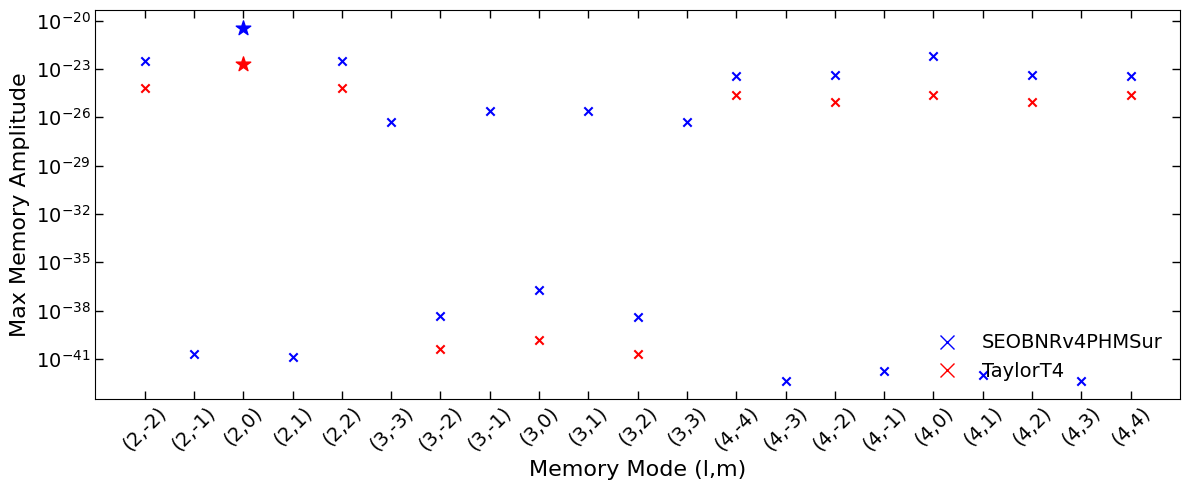

In [67]:
plt.figure(figsize=(12, 5))
for i, (mode, mem) in enumerate(zip(modes_taylor, max_memory_taylor)):
    if i == 2:
        plt.scatter(mode, mem, color='r', marker='*', s=120 )
    else:
        plt.scatter(mode, mem, color='red', marker='x')
for i, (mode, mem) in enumerate(zip(modes_surr, max_memory_surr)):
    if i == 2:
        plt.scatter(mode, mem, color='blue', marker='*', s=120)
    else:
        plt.scatter(mode, mem, color='blue', marker='x')
plt.yscale('log')
plt.xlabel('Memory Mode (l,m)')
plt.ylabel('Max Memory Amplitude')

plt.xticks(rotation=45)
# make a legend with custom markers
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='x', color='blue', label='SEOBNRv4PHMSur', markersize=10, linestyle='None'),
    Line2D([0], [0], marker='x', color='red', label='TaylorT4', markersize=10, linestyle='None')
]
plt.legend(handles=legend_elements, loc='lower right', frameon=False, fontsize=14)
plt.minorticks_off()
plt.tight_layout()
plt.show()

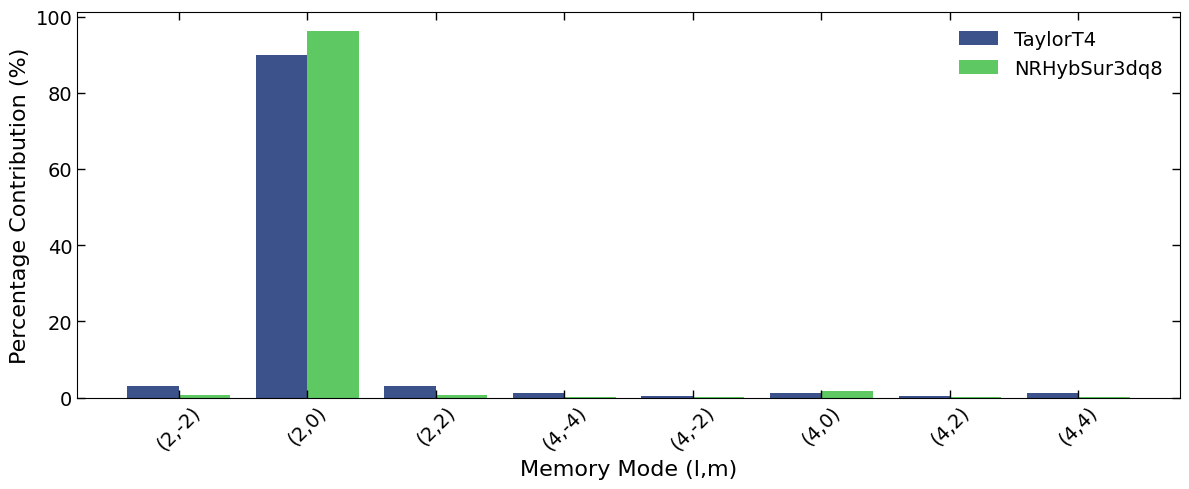

In [68]:
def mode_sort_key(mode):
    l, m = mode
    # Pour chaque l, trie d'abord m négatif (par valeur absolue croissante), puis m=0, puis m positif (par valeur croissante)
    return (l, abs(m), m < 0, m)

all_modes = sorted(set(hlm_dict.keys()) | set(hlm.keys()), key=mode_sort_key)

# Calculate percentage for each mode
total_taylor = np.sum(max_memory_taylor)
total_surr = np.sum(max_memory_surr)
percent_taylor = 100 * np.array(max_memory_taylor) / total_taylor
percent_surr = 100 * np.array(max_memory_surr) / total_surr
epsilon = 0.1  # threshold percentage
# Filter modes with percentage >= epsilon for at least one approximant
mask = (percent_taylor >= epsilon) | (percent_surr >= epsilon)
filtered_modes = np.array(modes_taylor)[mask]
filtered_taylor = percent_taylor[mask]
filtered_surr = percent_surr[mask]
x = np.arange(len(filtered_modes))

# Barplot parameters
bar_width = 0.4
cmap = plt.get_cmap('viridis')
color_taylor = cmap(0.25)
color_surr = cmap(0.75)

plt.figure(figsize=(12, 5))
plt.bar(x - bar_width/2, filtered_taylor, width=bar_width, color=color_taylor, label='TaylorT4')
plt.bar(x + bar_width/2, filtered_surr, width=bar_width, color=color_surr, label='NRHybSur3dq8')

plt.xlabel('Memory Mode (l,m)')
plt.ylabel('Percentage Contribution (%)')
plt.xticks(x, filtered_modes, rotation=45)
plt.tick_params(axis='y', which='both', direction='in')
# dont't show x-axis minor ticks
plt.minorticks_off()
plt.legend(loc='upper right', frameon=False, fontsize=14)
plt.tight_layout()
plt.show()

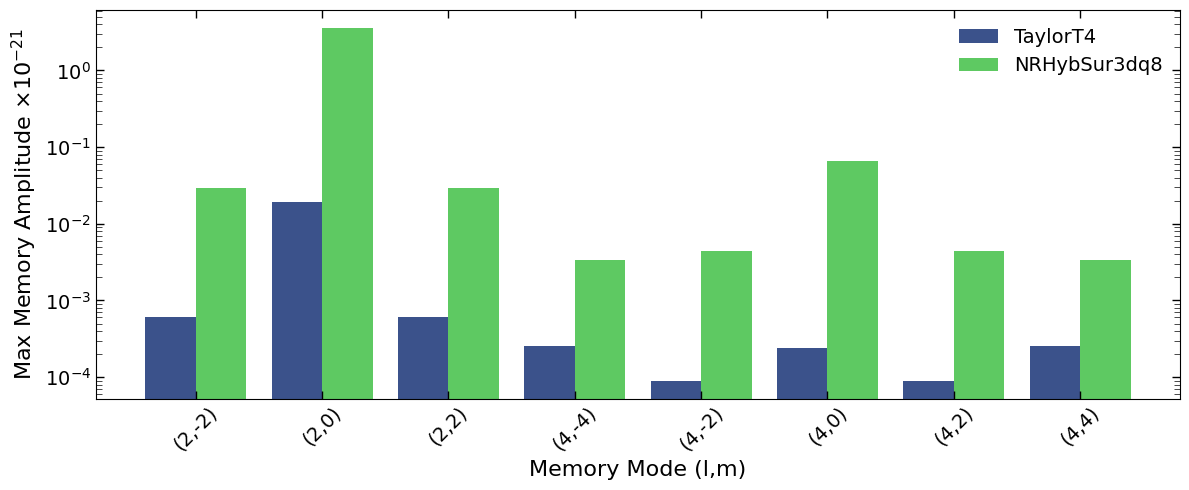

In [69]:
def mode_sort_key(mode):
    l, m = mode
    # Pour chaque l, trie d'abord m négatif (par valeur absolue croissante), puis m=0, puis m positif (par valeur croissante)
    return (l, abs(m), m < 0, m)

all_modes = sorted(set(modes_taylor) | set(modes_surr), key=lambda x: mode_sort_key(eval(x)))

# Filtrage des modes avec un seuil sur l’amplitude
epsilon = 1e-24  # ajuste selon tes données
max_memory_taylor = np.array(max_memory_taylor)
max_memory_surr = np.array(max_memory_surr)
mask = (max_memory_taylor >= epsilon) | (max_memory_surr >= epsilon)

filtered_modes = np.array(modes_taylor)[mask]
filtered_taylor = max_memory_taylor[mask]
filtered_surr = max_memory_surr[mask]
x = np.arange(len(filtered_modes))

bar_width = 0.4
cmap = plt.get_cmap('viridis')
color_taylor = cmap(0.25)
color_surr = cmap(0.75)

plt.figure(figsize=(12, 5))
plt.bar(x - bar_width/2, filtered_taylor*1e21, width=bar_width, color=color_taylor, label='TaylorT4')
plt.bar(x + bar_width/2, filtered_surr*1e21, width=bar_width, color=color_surr, label='NRHybSur3dq8')

plt.xlabel('Memory Mode (l,m)')
plt.ylabel(r'Max Memory Amplitude $\times 10^{-21}$')
plt.xticks(x, filtered_modes, rotation=45)
plt.tick_params(axis='y', which='both', direction='in')
plt.minorticks_off()
plt.legend(loc='upper right', frameon=False, fontsize=14)
plt.yscale('log')
plt.tight_layout()
plt.show()

### Same but for only the waveform

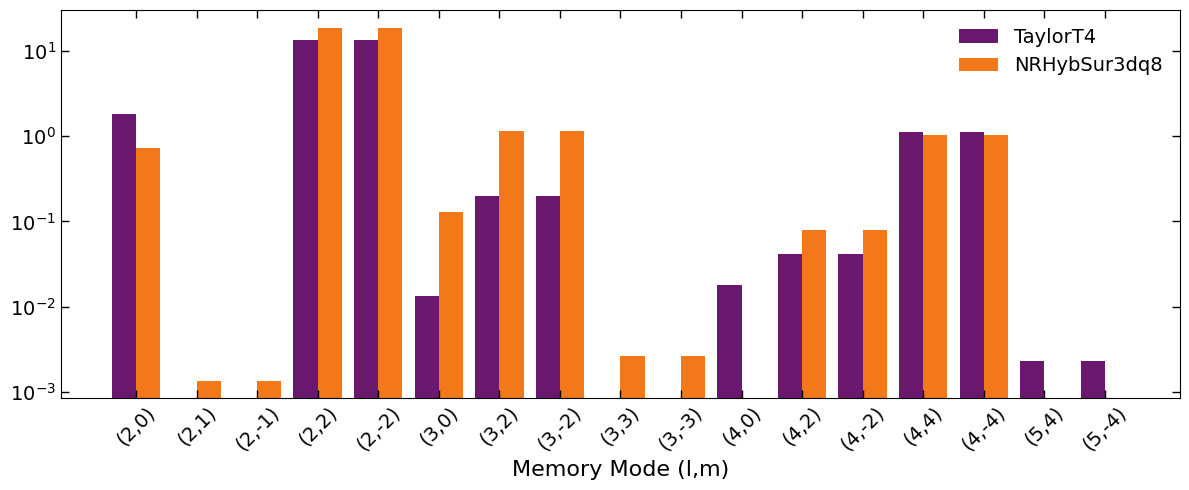

In [70]:
def mode_sort_key(mode):
    l, m = mode
    # Pour chaque l, trie d'abord m négatif (par valeur absolue croissante), puis m=0, puis m positif (par valeur croissante)
    return (l, abs(m), m < 0, m)

all_modes = sorted(set(hlm_dict.keys()) | set(hlm.keys()), key=mode_sort_key)

# Récupérer les max pour chaque mode, 0 si absent
h_modes_taylor = []
h_modes_surr = []
modes_labels = []
for mode in all_modes:
    # Taylor
    if mode in hlm_dict:
        hp, hc = hlm_dict[mode]
        h_modes_taylor.append(np.max(np.sqrt(hp**2 + hc**2)))
    else:
        h_modes_taylor.append(0)
    # Surrogate
    if mode in hlm:
        h_lm = hlm[mode]
        h_modes_surr.append(np.max(np.sqrt(h_lm.real**2 + h_lm.imag**2)))
    else:
        h_modes_surr.append(0)
    modes_labels.append(f"({mode[0]},{mode[1]})")

epsilon = 1e-24  # threshold 
mask = (np.array(h_modes_taylor) >= epsilon) | (np.array(h_modes_surr) >= epsilon)
filtered_modes_2 = np.array(modes_labels)[mask]
filtered_taylor_2 = np.array(h_modes_taylor)[mask]
filtered_surr_2 = np.array(h_modes_surr)[mask]
x_2 = np.arange(len(filtered_modes_2))



# Barplot parameters
bar_width = 0.4
cmap = plt.get_cmap('inferno')
color_taylor = cmap(0.3)
color_surr = cmap(0.7)

plt.figure(figsize=(12, 5))
plt.bar(x_2 - bar_width/2, filtered_taylor_2*1e21, width=bar_width, color=color_taylor, label='TaylorT4')
plt.bar(x_2 + bar_width/2, filtered_surr_2*1e21, width=bar_width, color=color_surr, label='NRHybSur3dq8')

plt.xlabel('Memory Mode (l,m)')
plt.yscale('log')
plt.xticks(x_2, filtered_modes_2, rotation=45)
plt.tick_params(axis='y', which='both', direction='in')
plt.minorticks_off()
plt.legend(loc='upper right', frameon=False, fontsize=14)
plt.tight_layout()
plt.show()

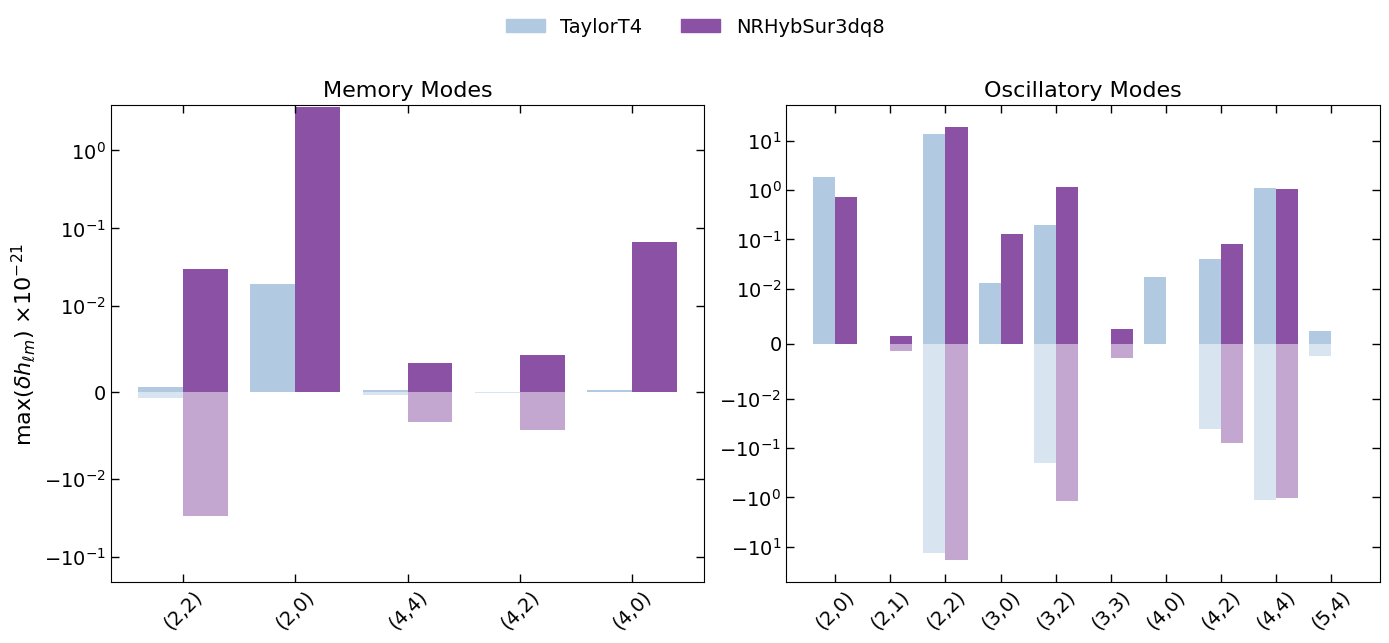

In [71]:
import matplotlib.patches as mpatches
from collections import defaultdict

def get_l_m(label):
    # label format: (l,m)
    l, m = label.strip('()').split(',')
    return int(l), int(m)

def group_modes(filtered_modes, taylor_vals, surr_vals):
    # Regroupe par (l, |m|) et sépare m>0 et m<0
    grouped = defaultdict(lambda: {'taylor_pos':0, 'taylor_neg':0, 'surr_pos':0, 'surr_neg':0})
    for i, label in enumerate(filtered_modes):
        l, m = get_l_m(label)
        key = (l, abs(m))
        if m > 0:
            grouped[key]['taylor_pos'] += taylor_vals[i]
            grouped[key]['surr_pos'] += surr_vals[i]
        elif m < 0:
            grouped[key]['taylor_neg'] += taylor_vals[i]
            grouped[key]['surr_neg'] += surr_vals[i]
        else:  # m=0
            grouped[key]['taylor_pos'] += taylor_vals[i]
            grouped[key]['surr_pos'] += surr_vals[i]
    return grouped

# Multiplie par 1e21
taylor_vals = filtered_taylor * 1e21
surr_vals = filtered_surr * 1e21
grouped = group_modes(filtered_modes, taylor_vals, surr_vals)

x_labels = [f"({l},{m})" for (l, m) in grouped.keys()]
x = np.arange(len(x_labels))

# Pour chaque barre, on empile m>0 (vers le haut) et m<0 (vers le bas)
taylor_pos = [grouped[key]['taylor_pos'] for key in grouped]
taylor_neg = [-grouped[key]['taylor_neg'] for key in grouped]  # vers le bas
surr_pos = [grouped[key]['surr_pos'] for key in grouped]
surr_neg = [-grouped[key]['surr_neg'] for key in grouped]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mémoire
bar_width = 0.4
cmap1 = plt.get_cmap('BuPu')
color_taylor1 = cmap1(0.3)
color_surr1 = cmap1(0.7)

axes[0].bar(x - bar_width/2, taylor_pos, width=bar_width, color=color_taylor1, label='TaylorT4 $m>0$ (mémoire)')
axes[0].bar(x - bar_width/2, taylor_neg, width=bar_width, color=color_taylor1, alpha=0.5, label='TaylorT4 $m<0$ (mémoire)')
axes[0].bar(x + bar_width/2, surr_pos, width=bar_width, color=color_surr1, label='SEOBNRv4PHMSur $m>0$ (mémoire)')
axes[0].bar(x + bar_width/2, surr_neg, width=bar_width, color=color_surr1, alpha=0.5, label='SEOBNRv4PHMSur $m<0$ (mémoire)')

axes[0].set_ylabel(r'max($\delta h_{\ell m}$) $\times 10^{-21}$')
axes[0].set_xticks(x, x_labels, rotation=45)
axes[0].set_title('Memory Modes', fontsize=16)
axes[0].set_yscale('symlog', linthresh=1e-2)
axes[0].minorticks_off()

# Pour le waveform, même logique (adapte filtered_modes_2, filtered_taylor_2, filtered_surr_2)
taylor2_vals = filtered_taylor_2 * 1e21
surr2_vals = filtered_surr_2 * 1e21
grouped2 = group_modes(filtered_modes_2, taylor2_vals, surr2_vals)
x2_labels = [f"({l},{m})" for (l, m) in grouped2.keys()]
x2 = np.arange(len(x2_labels))
taylor2_pos = [grouped2[key]['taylor_pos'] for key in grouped2]
taylor2_neg = [-grouped2[key]['taylor_neg'] for key in grouped2]
surr2_pos = [grouped2[key]['surr_pos'] for key in grouped2]
surr2_neg = [-grouped2[key]['surr_neg'] for key in grouped2]

cmap2 = plt.get_cmap('BuPu')
color_taylor2 = cmap2(0.3)
color_surr2 = cmap2(0.7)

axes[1].bar(x2 - bar_width/2, taylor2_pos, width=bar_width, color=color_taylor2, label='TaylorT4 $m>0$ (waveform)')
axes[1].bar(x2 - bar_width/2, taylor2_neg, width=bar_width, color=color_taylor2, alpha=0.5, label='TaylorT4 $m<0$ (waveform)')
axes[1].bar(x2 + bar_width/2, surr2_pos, width=bar_width, color=color_surr2, label='SEOBNRv4PHMSur $m>0$ (waveform)')
axes[1].bar(x2 + bar_width/2, surr2_neg, width=bar_width, color=color_surr2, alpha=0.5, label='SEOBNRv4PHMSur $m<0$ (waveform)')
axes[1].set_title('Oscillatory Modes', fontsize=16)
axes[1].set_yscale('symlog', linthresh=1e-2)
axes[1].set_xticks(x2, x2_labels, rotation=45)
axes[1].minorticks_off()

# Légende commune
handles = [
    mpatches.Patch(color=color_taylor1, label='TaylorT4'),
    mpatches.Patch(color=color_surr1, label='NRHybSur3dq8')
]
fig.legend(handles=handles, loc='upper center', ncol=4, frameon=False, fontsize=14, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()